# Importing the library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt

# Data Ingestion

In [3]:
flight_train=pd.read_excel(r"C:\FlightFarePrediction\notebooks\data\Data_Train.xlsx")
flight_train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


# Performing EDA

In [4]:
flight_train.shape

(10683, 11)

In [5]:
flight_train.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [6]:
flight_train.dropna(inplace = True)

In [7]:
flight_train.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [8]:
flight_train.describe()

,Price
count,10682.000000
mean,9087.214567
std,4611.548810
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [9]:
flight_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 1001.4+ KB


In [10]:
flight_train.duplicated().sum()

220

In [11]:
flight_train.drop_duplicates()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [12]:
flight_train["Journey_day"] = pd.to_datetime(flight_train.Date_of_Journey, format="%d/%m/%Y").dt.day
flight_train["Journey_month"] = pd.to_datetime(flight_train["Date_of_Journey"], format = "%d/%m/%Y").dt.month
flight_train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [13]:
# Since we have converted Date_of_Journey column into integers, Now we can drop as it is of no use.

flight_train.drop(["Date_of_Journey"], axis = 1, inplace = True)

In [14]:
# Departure time is when a plane leaves the gate. 
# Similar to Date_of_Journey we can extract values from Dep_Time

# Extracting Hours
flight_train["Dep_hour"] = pd.to_datetime(flight_train.Dep_Time).dt.hour

# Extracting Minutes
flight_train["Dep_min"] = pd.to_datetime(flight_train.Dep_Time).dt.minute







C:\Users\USER\AppData\Local\Temp\ipykernel_8924\653763408.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_train["Dep_hour"] = pd.to_datetime(flight_train.Dep_Time).dt.hour
C:\Users\USER\AppData\Local\Temp\ipykernel_8924\653763408.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_train["Dep_min"] = pd.to_datetime(flight_train.Dep_Time).dt.minute


In [15]:
flight_train.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


In [16]:
# Now we can drop Dep_Time as it is of no use
flight_train.drop(["Dep_Time"], axis = 1, inplace = True)

In [17]:
flight_train.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


In [18]:
# Arrival time is when the plane pulls up to the gate.
# Similar to Date_of_Journey we can extract values from Arrival_Time

# Extracting Hours
flight_train["Arrival_hour"] = pd.to_datetime(flight_train.Arrival_Time).dt.hour

# Extracting Minutes
flight_train["Arrival_min"] = pd.to_datetime(flight_train.Arrival_Time).dt.minute

# Now we can drop Arrival_Time as it is of no use
flight_train.drop(["Arrival_Time"], axis = 1, inplace = True)

C:\Users\USER\AppData\Local\Temp\ipykernel_8924\215507936.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_train["Arrival_hour"] = pd.to_datetime(flight_train.Arrival_Time).dt.hour
C:\Users\USER\AppData\Local\Temp\ipykernel_8924\215507936.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_train["Arrival_min"] = pd.to_datetime(flight_train.Arrival_Time).dt.minute


In [19]:
flight_train.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [20]:
# Time taken by plane to reach destination is called Duration
# It is the difference between Departure Time and Arrival time


# Assigning and converting Duration column into list
duration = list(flight_train["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:    # Check if duration contains only hour or mins
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   # Adds 0 minute
        else:
            duration[i] = "0h " + duration[i]           # Adds 0 hour

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0]))    # Extract hours from duration
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))   # Extracts only minutes from duration

In [21]:
# Adding duration_hours and duration_mins list to train_data dataframe

flight_train["Duration_hours"] = duration_hours
flight_train["Duration_mins"] = duration_mins

In [22]:
flight_train.drop(["Duration"], axis = 1, inplace = True)
flight_train.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,4,45


 Handling Categorical Data
  One can find many ways to handle categorical data. Some of them categorical data are,

Nominal data --> data are not in any order --> OneHotEncoder is used in this case

Ordinal data --> data are in order --> LabelEncoder is used in this case

In [23]:
flight_train["Airline"].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [24]:
Airline=flight_train['Airline']
Airline=pd.get_dummies(Airline, drop_first=True, dtype=int)
Airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0


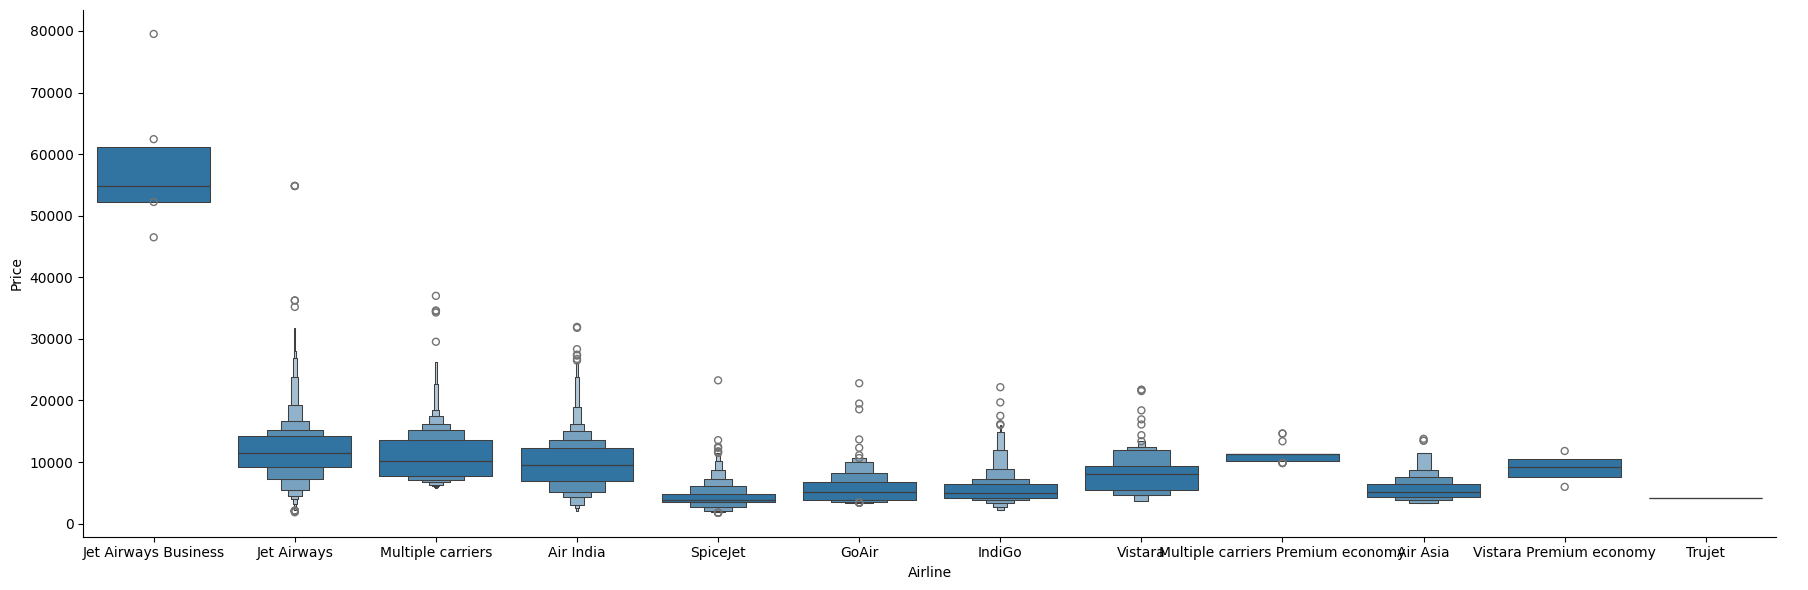

In [25]:
# From graph we can see that Jet Airways Business have the highest Price.
# Apart from the first Airline almost all are having similar median

# Airline vs Price
sns.catplot(y = "Price", x = "Airline", data = flight_train.sort_values("Price", ascending = False), kind="boxen", height = 6, aspect = 3)
plt.show()

In [26]:
flight_train["Source"].value_counts()

Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

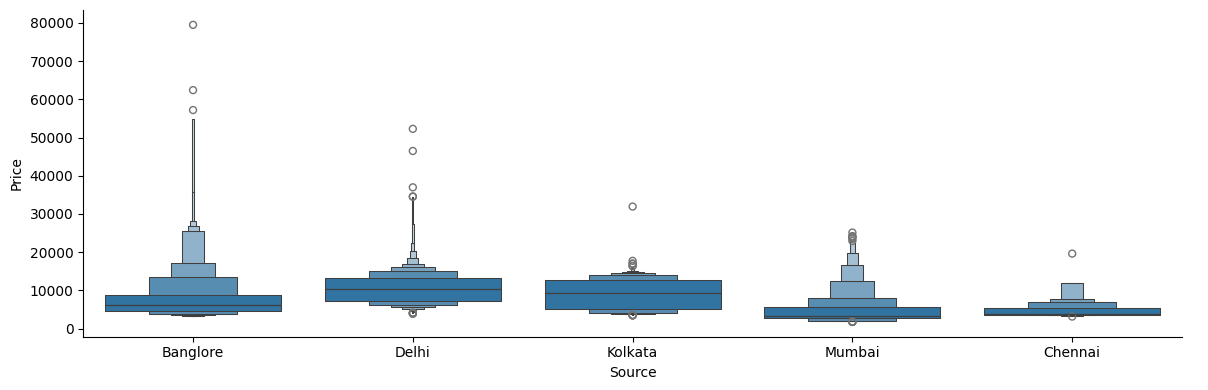

In [27]:
# Source vs Price

sns.catplot(y = "Price", x = "Source", data = flight_train.sort_values("Price", ascending = False), kind="boxen", height = 4, aspect = 3)
plt.show()

In [28]:
# As Source is Nominal Categorical data we will perform OneHotEncoding

Source = flight_train[["Source"]]

Source = pd.get_dummies(Source, drop_first= True, dtype=int)

Source.head()

,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,0,1,0
4,0,0,0,0


In [29]:
flight_train["Destination"].value_counts()

Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [30]:
# As Destination is Nominal Categorical data we will perform OneHotEncoding

Destination = flight_train[["Destination"]]

Destination = pd.get_dummies(Destination, drop_first = True, dtype=int)

Destination.head()

,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,0,0,0,1
1,0,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1


In [31]:
flight_train["Route"]

0                    BLR → DEL
1        CCU → IXR → BBI → BLR
2        DEL → LKO → BOM → COK
3              CCU → NAG → BLR
4              BLR → NAG → DEL
                 ...          
10678                CCU → BLR
10679                CCU → BLR
10680                BLR → DEL
10681                BLR → DEL
10682    DEL → GOI → BOM → COK
Name: Route, Length: 10682, dtype: object

In [32]:
# Additional_Info contains almost 80% no_info
# Route and Total_Stops are related to each other

flight_train.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [33]:
flight_train["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [34]:
# As this is case of Ordinal Categorical type we perform LabelEncoder
# Here Values are assigned with corresponding keys

flight_train.replace({"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}, inplace = True)

In [35]:
flight_train.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,35,4,45


In [36]:
# Concatenate dataframe --> train_data + Airline + Source + Destination

data_train = pd.concat([flight_train, Airline, Source, Destination], axis = 1)

In [37]:
data_train.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,...,Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,...,0,0,0,0,0,0,0,0,0,1
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,...,0,0,0,1,0,0,0,0,0,0
2,Jet Airways,Delhi,Cochin,2,13882,9,6,9,25,4,...,0,0,1,0,0,1,0,0,0,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,...,0,0,0,1,0,0,0,0,0,0
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,...,0,0,0,0,0,0,0,0,0,1


In [38]:
data_train.drop(["Airline", "Source", "Destination"], axis = 1, inplace = True)

In [39]:
data_train.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,...,Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,1,5,5,50,13,15,7,25,...,0,0,0,1,0,0,0,0,0,0
2,2,13882,9,6,9,25,4,25,19,0,...,0,0,1,0,0,1,0,0,0,0
3,1,6218,12,5,18,5,23,30,5,25,...,0,0,0,1,0,0,0,0,0,0
4,1,13302,1,3,16,50,21,35,4,45,...,0,0,0,0,0,0,0,0,0,1


In [40]:
data_train.shape

(10682, 30)

# Test Data

Same operations with test data

In [41]:
flight_test = pd.read_excel(r"C:\FlightFarePrediction\notebooks\data\Test_set.xlsx")

In [42]:
flight_test.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


## EDA on Test Data set

In [43]:
flight_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          2671 non-null   object
 1   Date_of_Journey  2671 non-null   object
 2   Source           2671 non-null   object
 3   Destination      2671 non-null   object
 4   Route            2671 non-null   object
 5   Dep_Time         2671 non-null   object
 6   Arrival_Time     2671 non-null   object
 7   Duration         2671 non-null   object
 8   Total_Stops      2671 non-null   object
 9   Additional_Info  2671 non-null   object
dtypes: object(10)
memory usage: 208.8+ KB


In [44]:
flight_test.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64

In [45]:
# Date_of_Journey
flight_test["Journey_day"] = pd.to_datetime(flight_test.Date_of_Journey, format="%d/%m/%Y").dt.day
flight_test["Journey_month"] = pd.to_datetime(flight_test["Date_of_Journey"], format = "%d/%m/%Y").dt.month
flight_test.drop(["Date_of_Journey"], axis = 1, inplace = True)

In [46]:
# Dep_Time
flight_test["Dep_hour"] = pd.to_datetime(flight_test["Dep_Time"]).dt.hour
flight_test["Dep_min"] = pd.to_datetime(flight_test["Dep_Time"]).dt.minute
flight_test.drop(["Dep_Time"], axis = 1, inplace = True)

C:\Users\USER\AppData\Local\Temp\ipykernel_8924\237814560.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_test["Dep_hour"] = pd.to_datetime(flight_test["Dep_Time"]).dt.hour
C:\Users\USER\AppData\Local\Temp\ipykernel_8924\237814560.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_test["Dep_min"] = pd.to_datetime(flight_test["Dep_Time"]).dt.minute


In [47]:
flight_test.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Journey_day,Journey_month,Dep_hour,Dep_min
0,Jet Airways,Delhi,Cochin,DEL → BOM → COK,04:25 07 Jun,10h 55m,1 stop,No info,6,6,17,30
1,IndiGo,Kolkata,Banglore,CCU → MAA → BLR,10:20,4h,1 stop,No info,12,5,6,20
2,Jet Airways,Delhi,Cochin,DEL → BOM → COK,19:00 22 May,23h 45m,1 stop,In-flight meal not included,21,5,19,15
3,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,21:00,13h,1 stop,No info,21,5,8,0
4,Air Asia,Banglore,Delhi,BLR → DEL,02:45 25 Jun,2h 50m,non-stop,No info,24,6,23,55


In [48]:
# Arrival_Time
flight_test["Arrival_hour"] = pd.to_datetime(flight_test.Arrival_Time).dt.hour
flight_test["Arrival_min"] = pd.to_datetime(flight_test.Arrival_Time).dt.minute
flight_test.drop(["Arrival_Time"], axis = 1, inplace = True)


C:\Users\USER\AppData\Local\Temp\ipykernel_8924\3904131107.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_test["Arrival_hour"] = pd.to_datetime(flight_test.Arrival_Time).dt.hour
C:\Users\USER\AppData\Local\Temp\ipykernel_8924\3904131107.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_test["Arrival_min"] = pd.to_datetime(flight_test.Arrival_Time).dt.minute


In [49]:
flight_test.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,Jet Airways,Delhi,Cochin,DEL → BOM → COK,10h 55m,1 stop,No info,6,6,17,30,4,25
1,IndiGo,Kolkata,Banglore,CCU → MAA → BLR,4h,1 stop,No info,12,5,6,20,10,20
2,Jet Airways,Delhi,Cochin,DEL → BOM → COK,23h 45m,1 stop,In-flight meal not included,21,5,19,15,19,0
3,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,13h,1 stop,No info,21,5,8,0,21,0
4,Air Asia,Banglore,Delhi,BLR → DEL,2h 50m,non-stop,No info,24,6,23,55,2,45


### Extraction of hours and minutes from 'Duration'

In [50]:
# Duration
duration = list(flight_test["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:    # Check if duration contains only hour or mins
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   # Adds 0 minute
        else:
            duration[i] = "0h " + duration[i]           # Adds 0 hour

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0]))    # Extract hours from duration
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))   # Extracts only minutes from duration

In [51]:
# Adding Duration column to test set
flight_test["Duration_hours"] = duration_hours
flight_test["Duration_mins"] = duration_mins
flight_test.drop(["Duration"], axis = 1, inplace = True)

#### Handling Categorical Data

In [52]:
flight_test["Airline"].value_counts()
Airline = pd.get_dummies(flight_test["Airline"], drop_first= True)


In [53]:
flight_test["Source"].value_counts()
Source = pd.get_dummies(flight_test["Source"], drop_first= True)

In [54]:
flight_test["Destination"].value_counts()
Destination = pd.get_dummies(flight_test["Destination"], drop_first = True)

In [55]:
flight_test.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [56]:
flight_test.replace({"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}, inplace = True)

In [57]:
data_test = pd.concat([flight_test, Airline, Source, Destination], axis = 1)

In [58]:
data_test.drop(["Airline", "Source", "Destination"], axis = 1, inplace = True)

In [59]:
data_test.shape

(2671, 28)

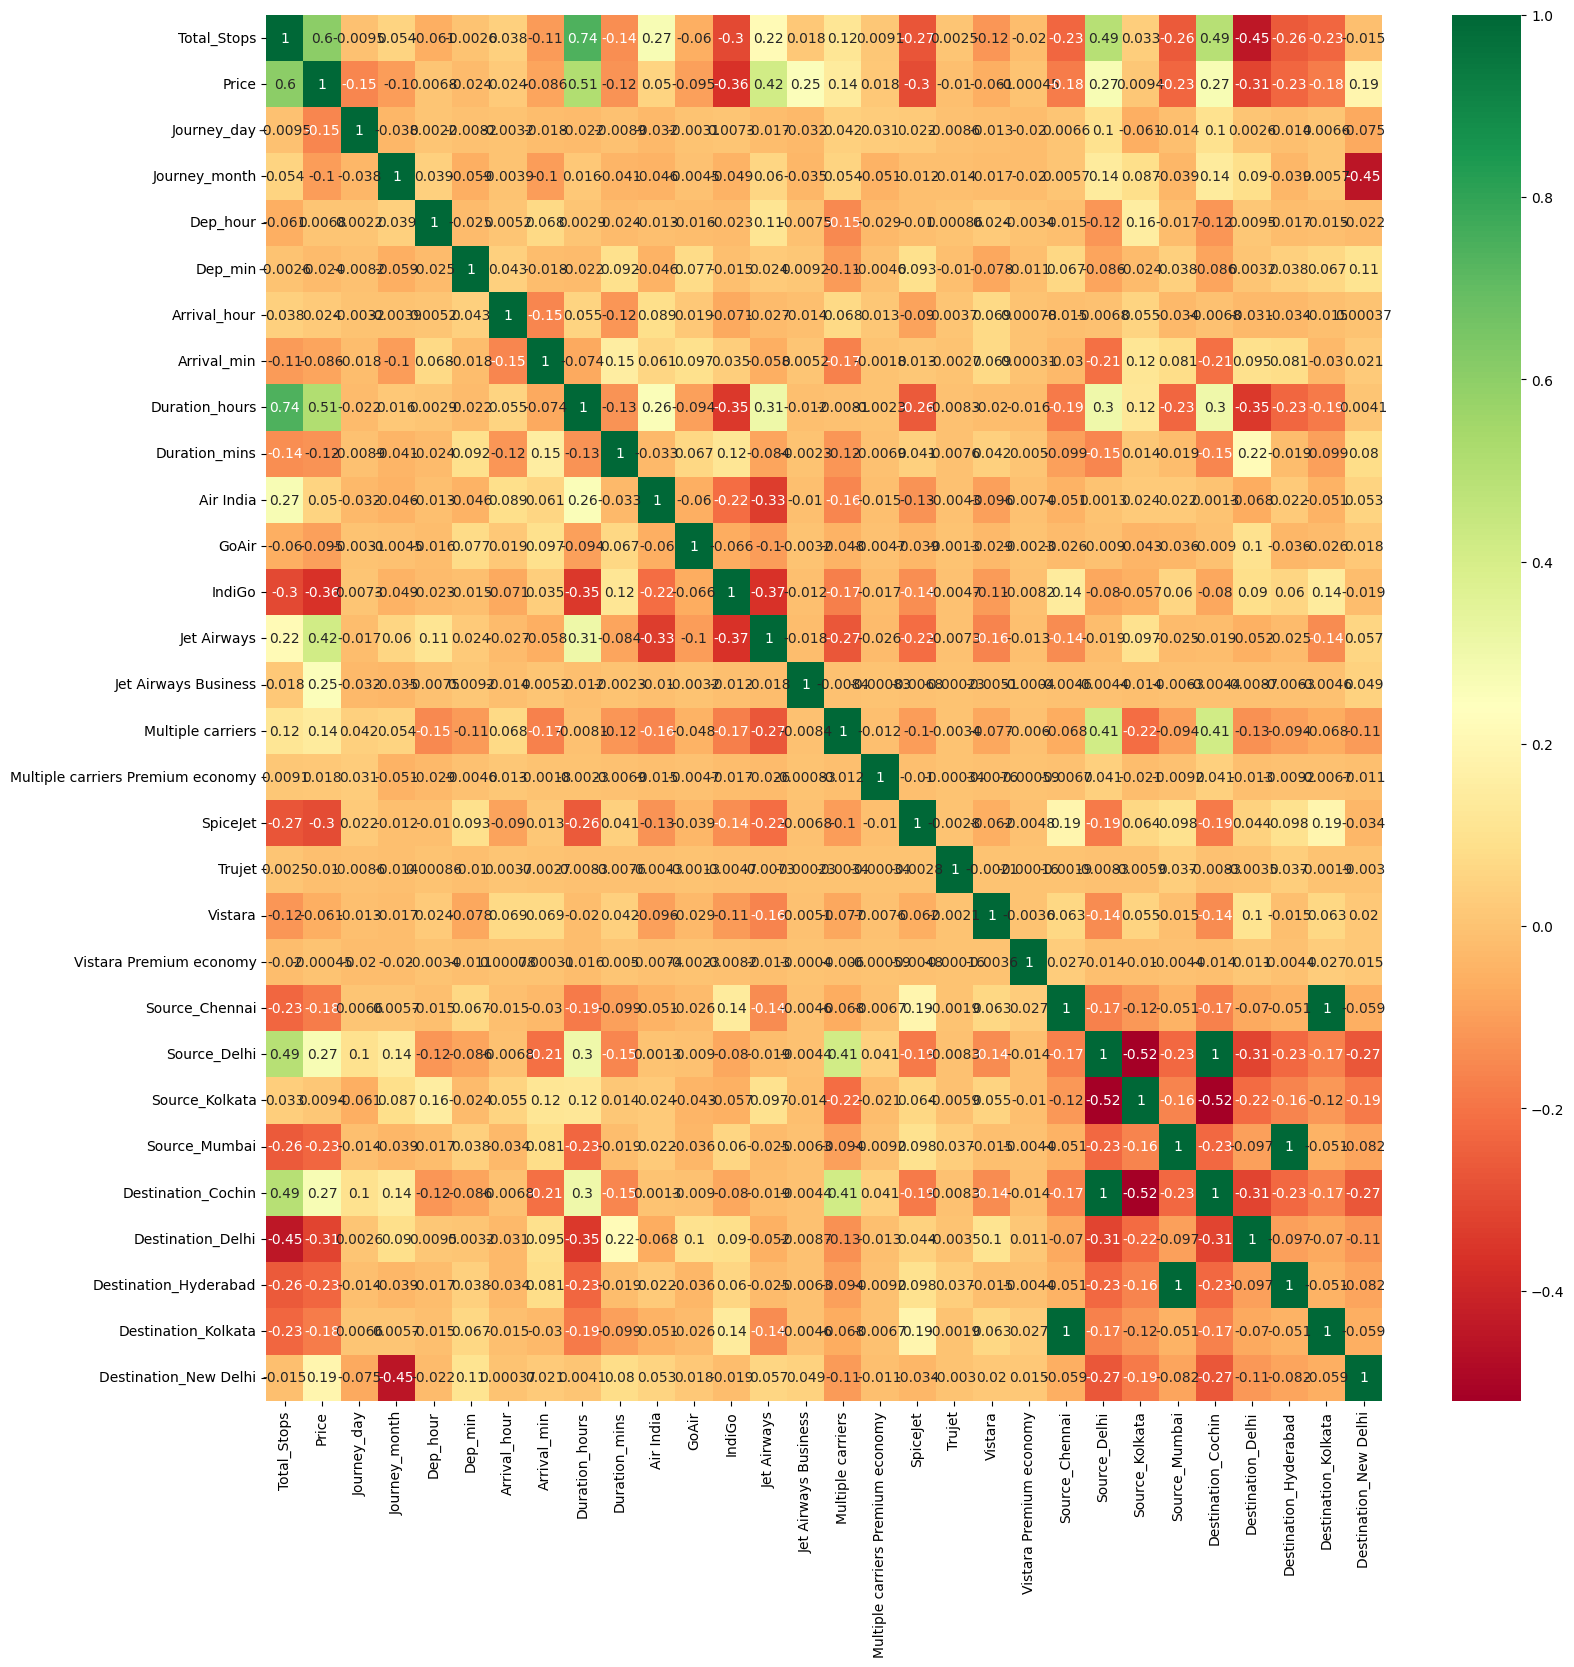

In [60]:
plt.figure(figsize = (18,18))
sns.heatmap(data_train.corr(), annot = True, cmap = "RdYlGn")

plt.show()

# Feature Selection

In [71]:
 
X = data_train.drop(["Price"],axis=1)
y = data_train["Price"]

# Model Fitting through RANDOM FOREST

In [63]:
from sklearn.model_selection import train_test_split

In [73]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=30)

In [74]:
from sklearn.ensemble import RandomForestRegressor
rfr= RandomForestRegressor()
rfr.fit(X_train, y_train)

RandomForestRegressor()

In [75]:
pred=rfr.predict(X_test)

In [77]:
rfr.score(X_train, y_train)

0.9585418064746949

In [78]:
rfr.score(X_test, y_test)

0.8199160315699745

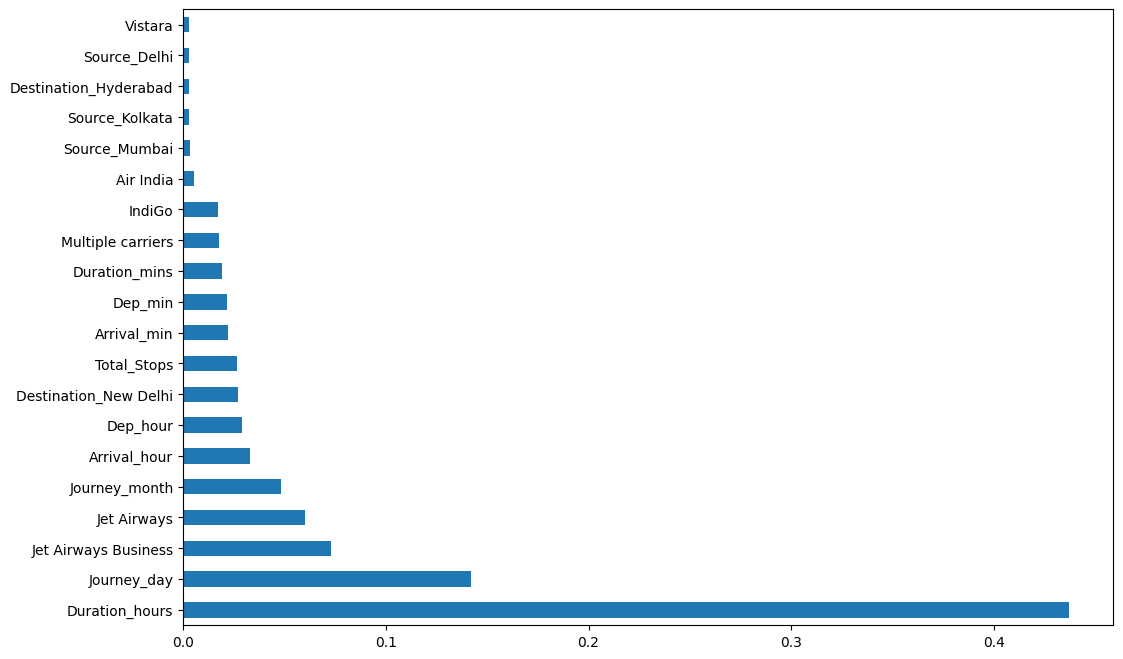

In [80]:
plt.figure(figsize = (12,8))
feat_importances = pd.Series(rfr.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_8924\1888287066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test - pred) # Checking error


<Axes: xlabel='Price', ylabel='Density'>

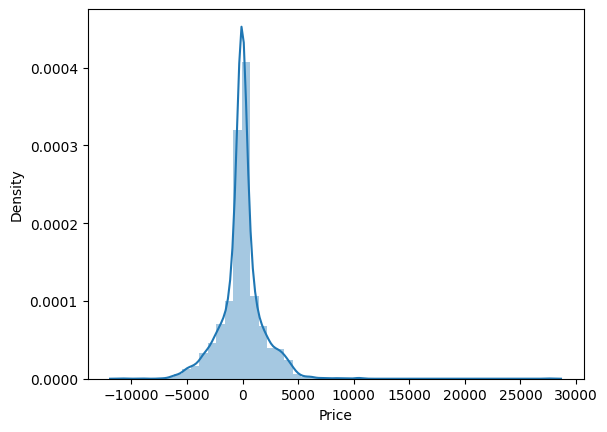

In [126]:
sns.distplot(y_test - pred) # Checking error

In [82]:
# Normal distribution curve (Bell Curve)

Text(0, 0.5, 'pred')

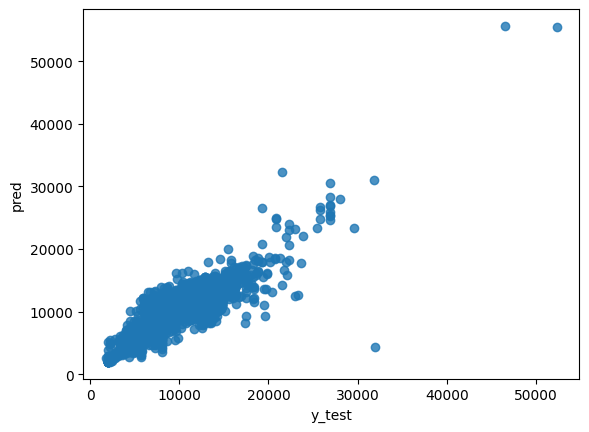

In [83]:
plt.scatter(y_test, pred, alpha=0.8)
plt.xlabel('y_test')
plt.ylabel('pred')

In [110]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor



In [111]:
## Train multiple models

models= {'Linear_regression':LinearRegression(), 
         'Elastic_net': ElasticNet(), 
         'Lasso':Lasso(), 
         'ridge':Ridge(), 
         'random_forest':RandomForestRegressor(), 
         'Gradient_boost': GradientBoostingRegressor(), 
         'Ada_boost': AdaBoostRegressor(), 
         'Decision_tree': DecisionTreeRegressor()}


In [119]:
import numpy as np
model_score = []


def train_predict(X_train,X_test,y_train,y_test):
    
    global models, model_score
    
    for model_name, model_obj in models.items():
        model = model_obj.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        r2score = r2_score(y_test, y_pred)

        print(f'{model_name}::\n')
        print('Training_score: ', model.score(X_train,y_train))
        
        print('Test_socre-r2score: ', r2score, '\n' )    
        
        model_score.append({model_name:r2score})
    return model_score

In [120]:
train_predict(X_train, X_test, y_train, y_test)

Linear_regression::

Training_score:  0.6261916647448936
Test_socre-r2score:  0.6125420305123335 

Elastic_net::

Training_score:  0.42810018958697593
Test_socre-r2score:  0.45324076369505495 

Lasso::

Training_score:  0.6259204009109274
Test_socre-r2score:  0.6139921180105756 

ridge::

Training_score:  0.6234385355169112
Test_socre-r2score:  0.6183197943109012 

random_forest::

Training_score:  0.9577810798541507
Test_socre-r2score:  0.8194563995558259 

Gradient_boost::

Training_score:  0.7887133616239812
Test_socre-r2score:  0.7710847333408981 

Ada_boost::

Training_score:  0.5562595719035482
Test_socre-r2score:  0.4873464650291671 

Decision_tree::

Training_score:  0.9760915141384803
Test_socre-r2score:  0.7194702800545321 



[{'Linear_regression': 0.6125420305123335},
 {'Elastic_net': 0.45324076369505495},
 {'Lasso': 0.6139921180105756},
 {'ridge': 0.6183197943109012},
 {'random_forest': 0.8194563995558259},
 {'Gradient_boost': 0.7710847333408981},
 {'Ada_boost': 0.4873464650291671},
 {'Decision_tree': 0.7194702800545321}]

In [121]:
# model_score
best_model = max(model_score, key=lambda x: list(x.values())[0])
best_model

{'random_forest': 0.8194563995558259}

In [122]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
min_max = MinMaxScaler()

In [123]:
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns = scaler.get_feature_names_out())
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns= scaler.get_feature_names_out())

In [124]:
X_train_minmax = pd.DataFrame(min_max.fit_transform(X_train), columns = min_max.get_feature_names_out())
X_test_minmax = pd.DataFrame(min_max.transform(X_test), columns= min_max.get_feature_names_out())

In [125]:
train_predict(X_train_scaled, X_test_scaled , y_train, y_test)

Linear_regression::

Training_score:  0.6261594597259251
Test_socre-r2score:  0.612412631385723 

Elastic_net::

Training_score:  0.5848503278776139
Test_socre-r2score:  0.5914955062327124 

Lasso::

Training_score:  0.6261871625430975
Test_socre-r2score:  0.6126089094949543 

ridge::

Training_score:  0.626191564057523
Test_socre-r2score:  0.6125522907546014 

random_forest::

Training_score:  0.9581864169815156
Test_socre-r2score:  0.8195878712614608 

Gradient_boost::

Training_score:  0.7887133616239813
Test_socre-r2score:  0.77109570144629 

Ada_boost::

Training_score:  0.46418560483134297
Test_socre-r2score:  0.3380368805252001 

Decision_tree::

Training_score:  0.9760915141384803
Test_socre-r2score:  0.6903124057977632 



[{'Linear_regression': 0.6125420305123335},
 {'Elastic_net': 0.45324076369505495},
 {'Lasso': 0.6139921180105756},
 {'ridge': 0.6183197943109012},
 {'random_forest': 0.8194563995558259},
 {'Gradient_boost': 0.7710847333408981},
 {'Ada_boost': 0.4873464650291671},
 {'Decision_tree': 0.7194702800545321},
 {'Linear_regression': 0.612412631385723},
 {'Elastic_net': 0.5914955062327124},
 {'Lasso': 0.6126089094949543},
 {'ridge': 0.6125522907546014},
 {'random_forest': 0.8195878712614608},
 {'Gradient_boost': 0.77109570144629},
 {'Ada_boost': 0.3380368805252001},
 {'Decision_tree': 0.6903124057977632}]

In [127]:
print('MAE:', mean_absolute_error(y_test, pred))
print('MSE:', mean_squared_error(y_test, pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred)))
print('R2score:', r2_score(y_test, pred))

MAE: 1175.4457184831374
MSE: 3523427.047769358
RMSE: 1877.0793930383866
R2score: 0.8199160315699745


# HyperParameter Tuning

In [128]:
from sklearn.model_selection import RandomizedSearchCV

In [129]:
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1200, num = 12)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(5, 30, num = 6)]
min_samples_split = [2, 5, 10, 15, 100]
min_samples_leaf = [1, 2, 5, 10]

In [130]:
ran_search = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf}

In [132]:
ran_search

{'n_estimators': [100,
  200,
  300,
  400,
  500,
  600,
  700,
  800,
  900,
  1000,
  1100,
  1200],
 'max_features': ['auto', 'sqrt'],
 'max_depth': [5, 10, 15, 20, 25, 30],
 'min_samples_split': [2, 5, 10, 15, 100],
 'min_samples_leaf': [1, 2, 5, 10]}

In [133]:
rf_random = RandomizedSearchCV(estimator = rfr, param_distributions = ran_search, scoring='neg_mean_squared_error', n_iter = 10, cv = 5, verbose=2, random_state=42, n_jobs = 1)

In [134]:
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   9.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   8.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   8.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   6.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   9.0s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=  14.8s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=1100; total time=  14.7s
[CV] END max_depth=15, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimator

c:\FlightFarePrediction\env\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "c:\FlightFarePrediction\env\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\FlightFarePrediction\env\lib\site-packages\sklearn\base.py", line 1145, in wrapper
    estimator._validate_params()
  File "c:\FlightFarePrediction\env\lib\site-packages\sklearn\base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "c:\FlightFarePrediction\env\lib

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=1,
                   param_distributions={'max_depth': [5, 10, 15, 20, 25, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 5, 10],
                                        'min_samples_split': [2, 5, 10, 15,
                                                              100],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100,
                                                         1200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [135]:
rf_random.best_params_

{'n_estimators': 1000,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 25}

In [136]:
y_prediction = rf_random.predict(X_test)

C:\Users\USER\AppData\Local\Temp\ipykernel_8924\653982018.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-y_prediction)


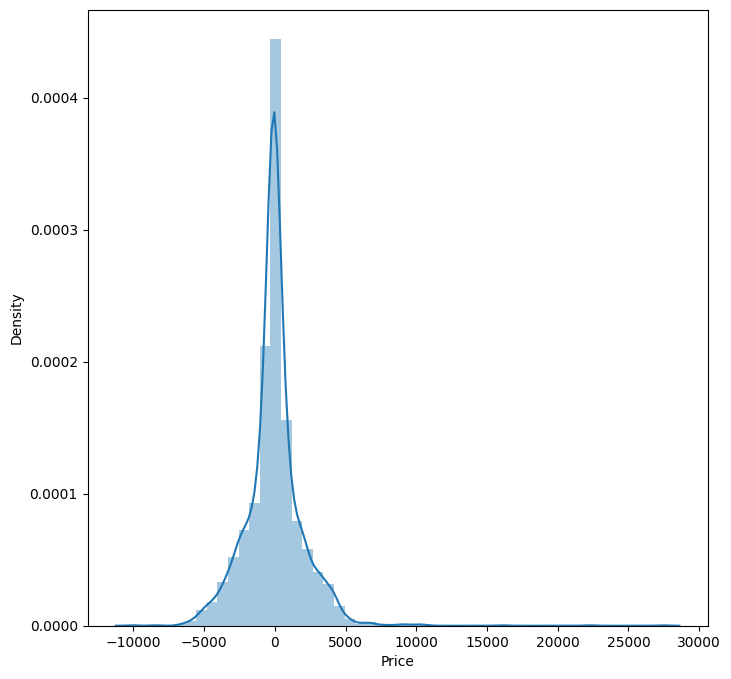

In [137]:
plt.figure(figsize = (8,8))
sns.distplot(y_test-y_prediction)
plt.show()

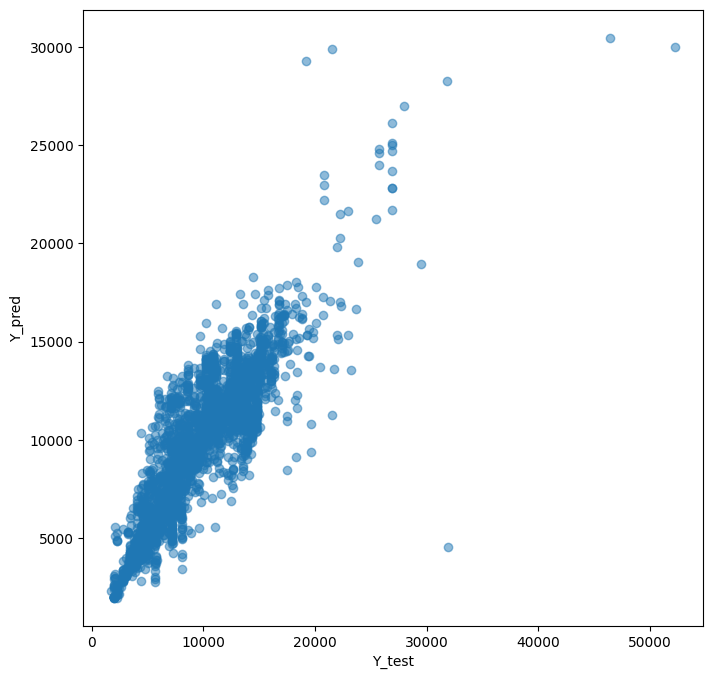

In [138]:
plt.figure(figsize = (8,8))
plt.scatter(y_test, y_prediction, alpha = 0.5)
plt.xlabel("Y_test")
plt.ylabel("Y_pred")
plt.show()

In [139]:
print('MAE:', mean_absolute_error(y_test, y_prediction))
print('MSE:', mean_squared_error(y_test, y_prediction))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_prediction)))
print('R2score:', r2_score(y_test, y_prediction))

MAE: 1291.866484315288
MSE: 4054414.289700317
RMSE: 2013.5576201589854
R2score: 0.7927770307005856
